In [ ]:
# Credit Risk Prediction Using K-Nearest Neighbors (KNN)

## 📌 Project Overview

This project focuses on predicting **loan approval/risk status** using the **K-Nearest Neighbors (KNN)** classification algorithm. The project demonstrates a complete machine learning workflow, starting from data exploration and preprocessing to model training and evaluation.

The dataset contains information about applicants such as age, income, home ownership, employment length, loan intent, loan grade, loan amount, interest rate, and previous credit default information.

The project includes **data cleaning, missing-value treatment, outlier handling, duplicate removal, exploratory data analysis (EDA), categorical encoding, class-imbalance handling using SMOTE, feature scaling, KNN model training, and model evaluation**.

## 🎯 Objectives

* Understand and explore the credit risk dataset.
* Identify and handle missing values.
* Detect and treat potential outliers.
* Remove duplicate records.
* Perform exploratory data analysis to understand feature relationships.
* Convert categorical variables into numerical form.
* Handle class imbalance using SMOTE.
* Standardize features for distance-based KNN classification.
* Train a KNN classification model.
* Evaluate the model using a confusion matrix, accuracy, precision, recall, and F1-score.

## 🛠️ Technologies & Libraries

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* imbalanced-learn (SMOTE)
* Google Colab / Jupyter Notebook

## 🤖 Machine Learning Algorithm

### K-Nearest Neighbors (KNN)

KNN is a supervised machine learning algorithm used for classification. It predicts the class of a new observation based on the classes of its nearest neighboring observations.

In this project, the model is configured with:

```python
KNeighborsClassifier(n_neighbors=7)
```

Before applying KNN, the numerical features are standardized using `StandardScaler`, since KNN relies on distance calculations.

## 🔄 Machine Learning Workflow

```text
Dataset
   ↓
Data Understanding
   ↓
Missing Value Treatment
   ↓
Outlier Handling
   ↓
Duplicate Removal
   ↓
Exploratory Data Analysis
   ↓
Categorical Encoding
   ↓
Feature / Target Separation
   ↓
Train-Test Split
   ↓
Class Imbalance Detection
   ↓
SMOTE
   ↓
Feature Scaling
   ↓
KNN Model Training
   ↓
Prediction
   ↓
Model Evaluation
```

## 📊 Model Results

The trained KNN model achieved an **accuracy of approximately 82.54%** on the test dataset.

The classification report produced the following results:

| Class        | Precision | Recall | F1-Score |
| ------------ | --------: | -----: | -------: |
| 0            |      0.92 |   0.85 |     0.88 |
| 1            |      0.58 |   0.73 |     0.64 |
| **Accuracy** |           |        | **0.83** |

The confusion matrix was:

```text
[[4326, 747],
 [ 385, 1026]]
```

These results demonstrate the importance of evaluating classification models using multiple metrics rather than relying only on accuracy.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/credit_risk_dataset.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [2]:
df.shape

(32581, 12)

In [3]:
df.ndim

2

In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [8]:
df[df["person_emp_length"] > 40]


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25


In [9]:
df["person_emp_length"] = df["person_emp_length"].replace(123, np.nan)

In [10]:
df["person_emp_length"].fillna(df["person_emp_length"].median(),inplace=True)
df["loan_int_rate"].fillna(df['loan_int_rate'].median(),inplace=True)

/tmp/ipykernel_15781/2423552619.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["person_emp_length"].fillna(df["person_emp_length"].median(),inplace=True)
/tmp/ipykernel_15781/2423552619.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

In [11]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [12]:
df.duplicated().sum()

np.int64(165)

In [13]:
df[df.duplicated()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
32172,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12
32259,39,40000,OWN,4.0,VENTURE,B,1000,10.37,0,0.03,N,16


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

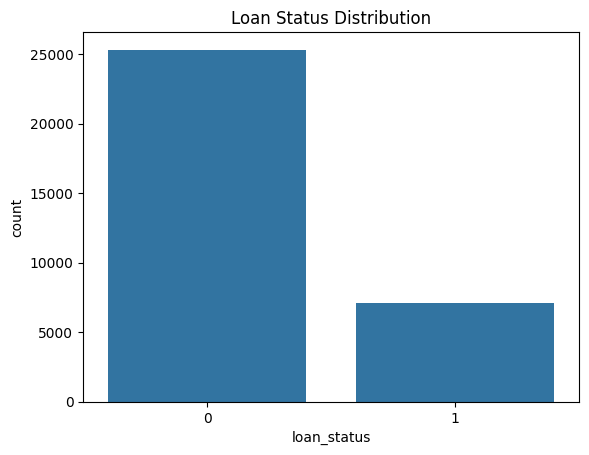

In [16]:
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.show()

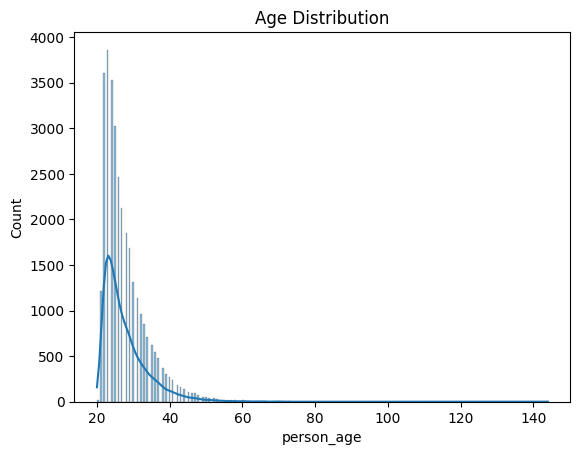

In [17]:
sns.histplot(data=df, x="person_age", kde=True)
plt.title("Age Distribution")
plt.show()

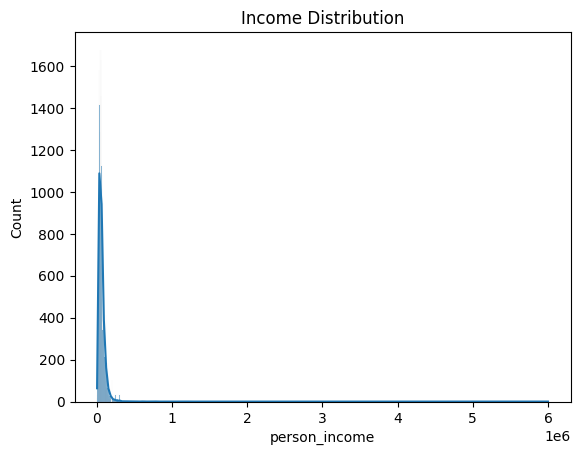

In [18]:
sns.histplot(data=df, x="person_income", kde=True)
plt.title("Income Distribution")
plt.show()

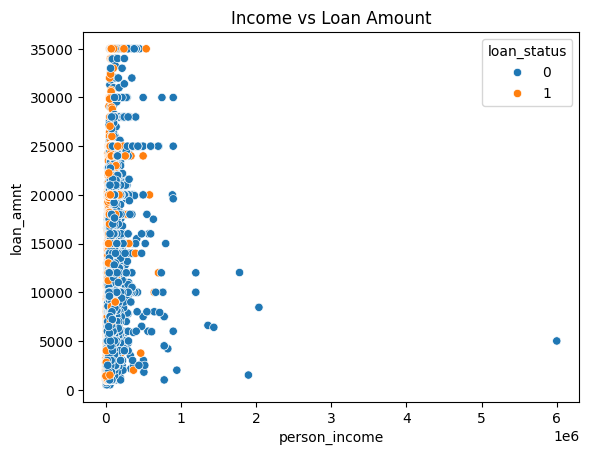

In [19]:
sns.scatterplot(data=df,x="person_income",y="loan_amnt",hue="loan_status")
plt.title("Income vs Loan Amount")
plt.show()

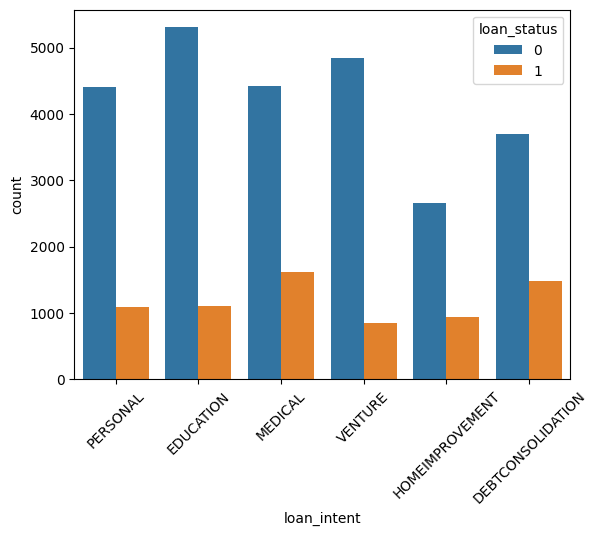

In [20]:
sns.countplot(data=df,x="loan_intent",hue="loan_status")
plt.xticks(rotation=45)
plt.show()

<Axes: >

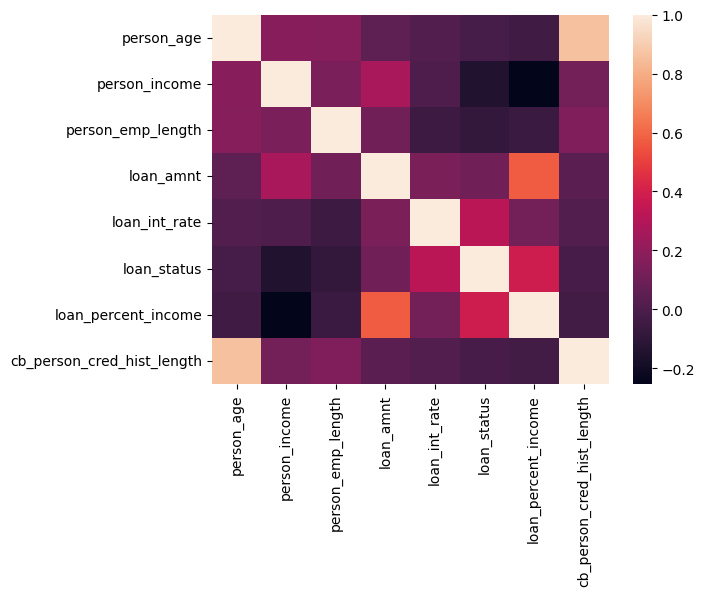

In [21]:
c = df.corr(numeric_only=True)
sns.heatmap(c)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  object 
 3   person_emp_length           32416 non-null  float64
 4   loan_intent                 32416 non-null  object 
 5   loan_grade                  32416 non-null  object 
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               32416 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  object 
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


In [23]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
lst = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for i in lst:
  df[i] = lab.fit_transform(df[i])


In [24]:
x = df.drop(columns='loan_status')
x

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,4.0,4,3,35000,16.02,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,0,1.0,4,2,5800,13.16,0.11,0,30
32577,54,120000,0,4.0,4,0,17625,7.49,0.15,0,19
32578,65,76000,3,3.0,2,1,35000,10.99,0.46,0,28
32579,56,150000,0,5.0,4,1,15000,11.48,0.10,0,26


In [25]:
x.shape

(32416, 11)

In [26]:
y = df['loan_status']
y

,loan_status
0,1
1,0
2,1
3,1
4,1
...,...
32576,0
32577,0
32578,1
32579,0


In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [28]:
x_train.shape

(25932, 11)

In [29]:
x_test.shape

(6484, 11)

In [30]:
y_train.shape

(25932,)

In [31]:
y_test.shape

(6484,)

In [32]:
y_train.value_counts()

,count
loan_status,
0,20254
1,5678


In [33]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_res,y_train_res = smote.fit_resample(x_train,y_train)

In [34]:
y_train_res.value_counts()

,count
loan_status,
0,20254
1,20254


In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_res = scaler.fit_transform(x_train_res)
x_test = scaler.transform(x_test)

In [36]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_res,y_train_res)

KNeighborsClassifier(n_neighbors=7)

In [37]:
y_pred = knn.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [38]:
y_test.values

array([0, 1, 0, ..., 0, 0, 0])

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test,y_pred)
cm


array([[4326,  747],
       [ 385, 1026]])

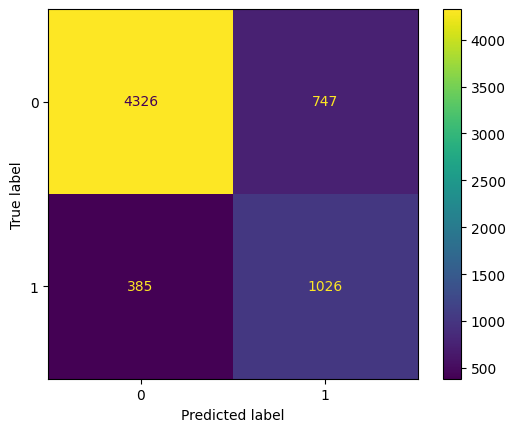

In [40]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [41]:
score = accuracy_score(y_test,y_pred)
score

0.8254164096236891

In [42]:
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      5073
           1       0.58      0.73      0.64      1411

    accuracy                           0.83      6484
   macro avg       0.75      0.79      0.76      6484
weighted avg       0.84      0.83      0.83      6484

